In [1]:
# Automobile Data:  https://archive.ics.uci.edu/ml/datasets/Automobile

In [2]:
# extension that allows you to execute SQL queries using "magic" commands (%sql)
!pip install ipython-sql   

## enables the execution of SQL queries directly within Jupyter cells.
%load_ext sql       

# for numerical computing, providing support for large, multi-dimensional arrays and high-level mathematical functions.
!pip install numpy       

# data visualization library
!pip install seaborn       

# plotting library 
!pip install matplotlib

# scientific library
!pip install scipy

In [3]:
import pandas as pd

import numpy as np

from scipy.stats import pearsonr


In [4]:
filepath='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/auto.csv'

In [5]:
df_automobile = pd.read_csv(filepath, header=None)

In [6]:
df_automobile.head(3)

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500


# Add Headers
Take a look at the data set. Pandas automatically set the header with an integer starting from 0

To better describe the data, you can introduce a header. This information is available at: https://archive.ics.uci.edu/ml/datasets/Automobile.
Thus, you have to add headers manually.

First, create a list "headers" that include all column names in order. Then, use dataframe.columns = headers to replace the headers with the list you created.

In [7]:
# create headers list
headers = ["symboling","normalized-losses","make","fuel-type","aspiration", "num-of-doors","body-style",
         "drive-wheels","engine-location","wheel-base", "length","width","height","curb-weight","engine-type",
         "num-of-cylinders", "engine-size","fuel-system","bore","stroke","compression-ratio","horsepower",
         "peak-rpm","city-mpg","highway-mpg","price"]
print("headers\n", headers)

headers
 ['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']


In [8]:
df_automobile.columns = headers
df_automobile.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price'],
      dtype='object')

In [9]:
df_automobile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

# data pre-processing

In [10]:
# standardization of column names
# Replace spaces with underscores in all column names
df_automobile.columns = df_automobile.columns.str.replace(' ', '_')

# Replace "-" with underscores in all column names
df_automobile.columns = df_automobile.columns.str.replace('-', '_')

# convert all to lowercase
df_automobile.columns = df_automobile.columns.str.lower()


* Replace the '?' entries

In [11]:
# Replace the '?' entries in the dataset with NaN value
df_automobile.replace('?',np.nan, inplace = True)

* identify these missing values

In [12]:
missing_data = df_automobile.isnull()
missing_data.head(5)

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


* a for loop in Python can quickly figure out the number of missing values in each column

In [13]:
for column in missing_data.columns.values.tolist():
    print(column)
    print (missing_data[column].value_counts())
    print("")    

symboling
symboling
False    205
Name: count, dtype: int64

normalized_losses
normalized_losses
False    164
True      41
Name: count, dtype: int64

make
make
False    205
Name: count, dtype: int64

fuel_type
fuel_type
False    205
Name: count, dtype: int64

aspiration
aspiration
False    205
Name: count, dtype: int64

num_of_doors
num_of_doors
False    203
True       2
Name: count, dtype: int64

body_style
body_style
False    205
Name: count, dtype: int64

drive_wheels
drive_wheels
False    205
Name: count, dtype: int64

engine_location
engine_location
False    205
Name: count, dtype: int64

wheel_base
wheel_base
False    205
Name: count, dtype: int64

length
length
False    205
Name: count, dtype: int64

width
width
False    205
Name: count, dtype: int64

height
height
False    205
Name: count, dtype: int64

curb_weight
curb_weight
False    205
Name: count, dtype: int64

engine_type
engine_type
False    205
Name: count, dtype: int64

num_of_cylinders
num_of_cylinders
False    205
Nam

* Calculate the mean value for the "normalized-losses" column 

In [14]:
avg_norm_loss = df_automobile["normalized_losses"].astype("float").mean(axis=0)
print("Average of normalized_losses:", avg_norm_loss)

Average of normalized_losses: 122.0


* Replace "NaN" with mean value in "normalized-losses" column

In [15]:
df_automobile["normalized_losses"] = df_automobile["normalized_losses"].replace(np.nan, avg_norm_loss)

* Calculate the mean value for the "bore" column

In [16]:
avg_bore=df_automobile['bore'].astype('float').mean(axis=0)
print("Average of bore:", avg_bore)

Average of bore: 3.3297512437810943


* Replace "NaN" with the mean value in the "bore" column

In [17]:
df_automobile["bore"] = df_automobile["bore"].replace(np.nan, avg_bore)

* replace NaN in "stroke" column with the mean value.

In [18]:
#Calculate the mean vaule for "stroke" column
avg_stroke = df_automobile["stroke"].astype("float").mean(axis = 0)
print("Average of stroke:", avg_stroke)

# replace NaN by mean value in "stroke" column
df_automobile["stroke"] = df_automobile["stroke"].replace(np.nan, avg_stroke)

Average of stroke: 3.255422885572139


* Calculate the mean value for the "horsepower" column

In [19]:
df_automobile["horsepower"]=df_automobile["horsepower"].astype("float")

In [20]:
avg_hp = df_automobile["horsepower"].astype("float").mean(axis = 0)
print("Average of hp:", avg_hp)

# replace NaN by mean value in "horsepower" column
df_automobile["horsepower"] = df_automobile["horsepower"].replace(np.nan, avg_hp)

Average of hp: 104.25615763546799


* Calculate the mean value for "peak-rpm" column

In [21]:
df_automobile["peak_rpm"]=df_automobile["peak_rpm"].astype("float")

In [22]:
avg_peak_rpm = df_automobile["peak_rpm"].astype("float").mean(axis = 0)
print("Average of peak rpm:", avg_peak_rpm)

Average of peak rpm: 5125.369458128079


In [23]:
df_automobile["peak_rpm"] = df_automobile["peak_rpm"].replace(np.nan, avg_peak_rpm)

* replace the missing 'num-of-doors' values by the most frequent 

In [24]:
df_automobile['num_of_doors'].value_counts()

num_of_doors
four    114
two      89
Name: count, dtype: int64

In [25]:
df_automobile['num_of_doors'].value_counts().idxmax()

'four'

In [26]:
#replace the missing 'num-of-doors' values by the most frequent 
df_automobile["num_of_doors"] = df_automobile["num_of_doors"].replace(np.nan, "four")

*  drop all rows that do not have price data:

In [27]:
# simply drop whole row with NaN in "price" column
df_automobile.dropna(subset=["price"], axis=0, inplace=True)

# reset index, because we droped two rows
df_automobile.reset_index(drop=True, inplace=True)

In [28]:
df_automobile["price"]=df_automobile["price"].astype("float")

In [29]:
df_automobile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized_losses  201 non-null    object 
 2   make               201 non-null    object 
 3   fuel_type          201 non-null    object 
 4   aspiration         201 non-null    object 
 5   num_of_doors       201 non-null    object 
 6   body_style         201 non-null    object 
 7   drive_wheels       201 non-null    object 
 8   engine_location    201 non-null    object 
 9   wheel_base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb_weight        201 non-null    int64  
 14  engine_type        201 non-null    object 
 15  num_of_cylinders   201 non-null    object 
 16  engine_size        201 non

* saves the processed data for later analysis

In [30]:
df_automobile.to_csv('automobile_data.csv', index=False)

# Creating a relational database

In [31]:
import csv, sqlite3

In [32]:
con = sqlite3.connect("automobile.db")
cur = con.cursor()

%sql sqlite:///automobile.db

In [33]:
df_automobile.to_sql("automobile_data", con, if_exists='replace', index=False)

201

In [34]:
import matplotlib.pyplot as plt

import seaborn as sns

In [35]:
# Install 'prettytable' libraries using pip
!pip install prettytable

# Import the 'prettytable' library, which is used to display data in a formatted table
import prettytable

# Set the default display format for prettytable to 'DEFAULT' (i.e., a simple table format)
prettytable.DEFAULT = 'DEFAULT'


In [36]:
%sql SELECT * FROM automobile_data LIMIT 5;

 * sqlite:///automobile.db
Done.


symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
1,122.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


# Continuous Numerical Variables:
Continuous numerical variables are variables that may contain any value within some range. They can be of type "int64" or "float64". A great way to visualize these variables is by using scatterplots with fitted lines.

In order to start understanding the (linear) relationship between an individual variable and the price, we can use "regplot" which plots the scatterplot plus the fitted regression line for the data. This will be useful later on for visualizing the fit of the simple linear regression model as well.

* Analysis of the relationship between horsepower and fuel consumption in the city

 * sqlite:///automobile.db
Done.


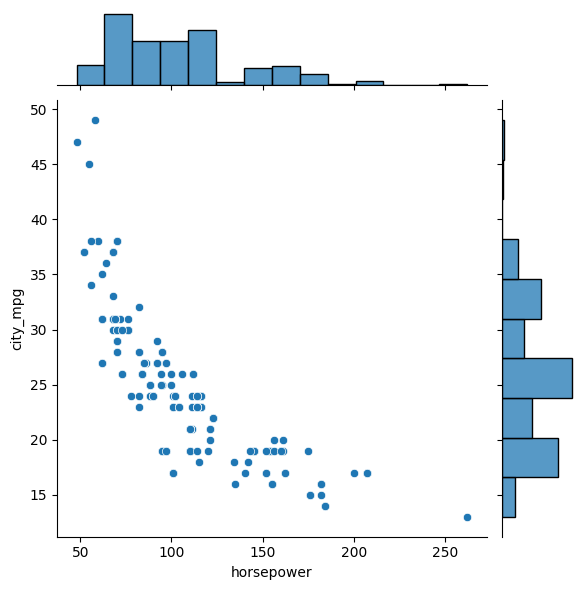

In [37]:
compres_vs_city = %sql SELECT horsepower , city_mpg FROM automobile_data;

plot = sns.jointplot(x='horsepower',y='city_mpg', data=compres_vs_city.DataFrame())

<Axes: xlabel='horsepower', ylabel='city_mpg'>

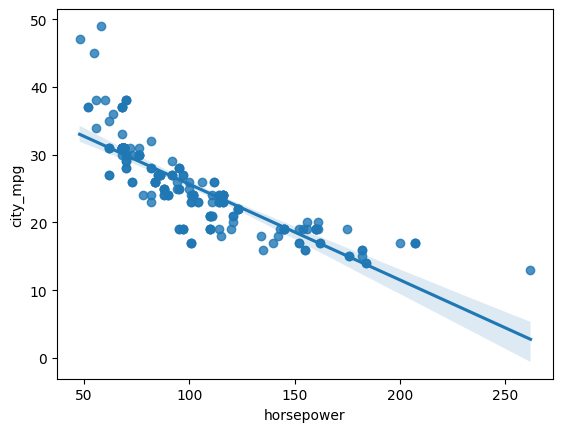

In [38]:
sns.regplot(x="horsepower", y="city_mpg", data=df_automobile)
# plt.ylim(0,)

In [39]:
from scipy.stats import pearsonr

pearson_coef, p_value = pearsonr(df_automobile["engine_size"], df_automobile["price"])

print(f"Pearson correlation: {pearson_coef}")
print(f"P_value: {p_value}")

Pearson correlation: 0.8723351674455184
P_value: 9.26549162219869e-64


* Analysis of the relationship between lenght and price

 * sqlite:///automobile.db
Done.


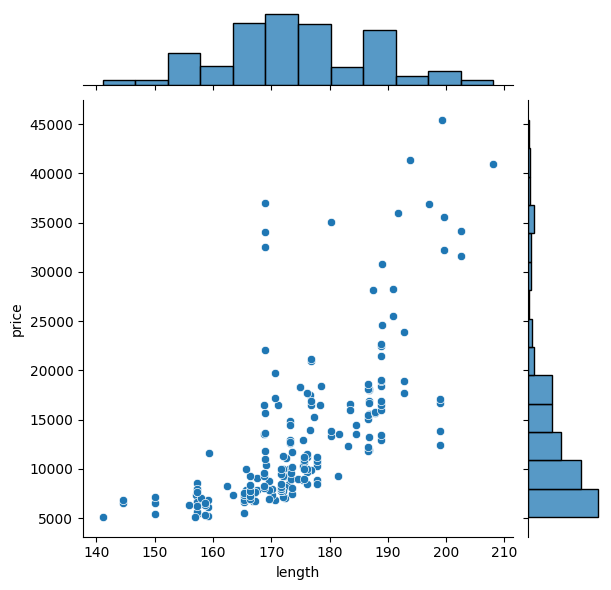

In [40]:
lenght_vs_price = %sql SELECT length , price FROM automobile_data;

plot = sns.jointplot(x='length',y='price', data=lenght_vs_price.DataFrame())


<Axes: xlabel='length', ylabel='price'>

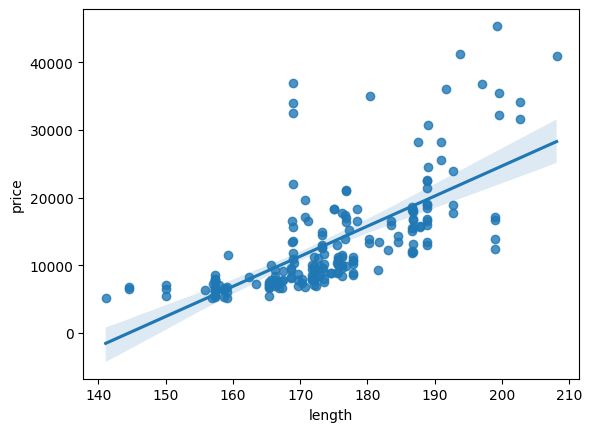

In [41]:
sns.regplot(x="length", y="price", data=df_automobile)

In [42]:
pearson_coef, p_value = pearsonr(df_automobile["length"], df_automobile["price"])

print(f"Pearson correlation: {pearson_coef}")
print(f"P_value: {p_value}")

Pearson correlation: 0.690628380448364
P_value: 8.016477466158899e-30


In [43]:
df_automobile["engine_size"]=df_automobile["engine_size"].astype("float")

In [44]:
# Passo 2: Importe a função pearsonr
from scipy.stats import pearsonr

# Exemplo de dados
x = [1, 2, 3, 4, 5]
y = [5, 4, 3, 2, 1]

# Passo 3: Calcule a correlação e o valor-p
correlacao, p_valor = pearsonr(x, y)

# Imprima os resultados
print(f"Coeficiente de correlação de Pearson: {correlacao}")
print(f"Valor-p: {p_valor}")

Coeficiente de correlação de Pearson: -1.0
Valor-p: 0.0


<Axes: xlabel='engine_size', ylabel='price'>

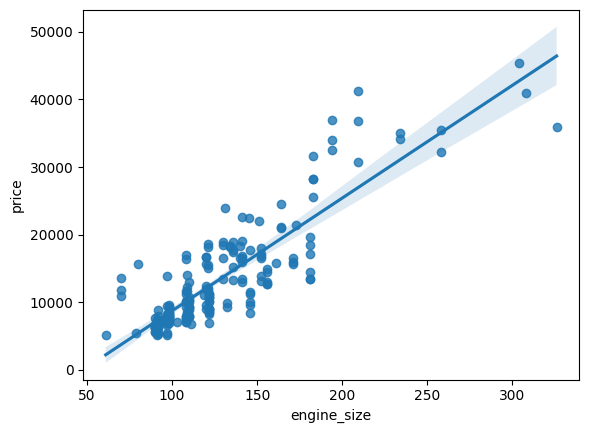

In [45]:
sns.regplot(x="engine_size", y="price", data=df_automobile)
# plt.ylim(0,)

In [46]:
from scipy.stats import pearsonr

pearson_coef, p_value = pearsonr(df_automobile["engine_size"], df_automobile["price"])

print(f"Pearson correlation: {pearson_coef}")
print(f"P_value: {p_value}")

Pearson correlation: 0.8723351674455184
P_value: 9.26549162219869e-64


* As the engine-size goes up, the price goes up: this indicates a positive direct correlation between these two variables. Engine size seems like a pretty good predictor of price since the regression line is almost a perfect diagonal line.

In [47]:
df_automobile[["engine_size", "price"]].corr()

,engine_size,price
engine_size,1.000000,0.872335
price,0.872335,1.000000


<Axes: xlabel='highway_mpg', ylabel='price'>

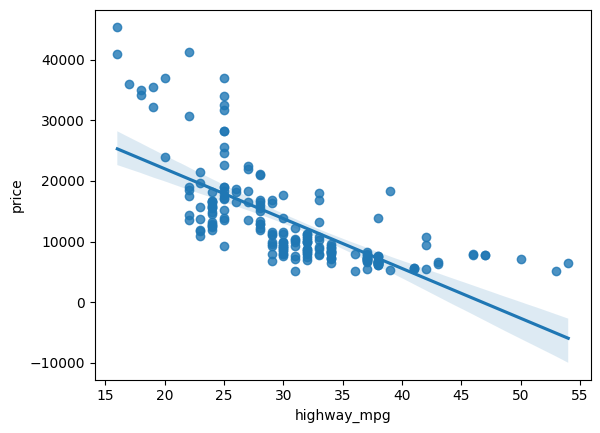

In [48]:
sns.regplot(x="highway_mpg", y="price", data=df_automobile)

In [49]:
# Quantifies the strength and direction of a linear relationship between the variables AGE and CHARGES
from scipy.stats import pearsonr

pearson_coef, p_value = pearsonr(df_automobile["highway_mpg"], df_automobile["price"])

print(f"Pearson correlation: {pearson_coef}")
print(f"P_value: {p_value}")

Pearson correlation: -0.7046922650589531
P_value: 1.749547114447559e-31


* As highway-mpg goes up, the price goes down: this indicates an inverse/negative relationship between these two variables. Highway mpg could potentially be a predictor of price.

<Axes: xlabel='peak_rpm', ylabel='price'>

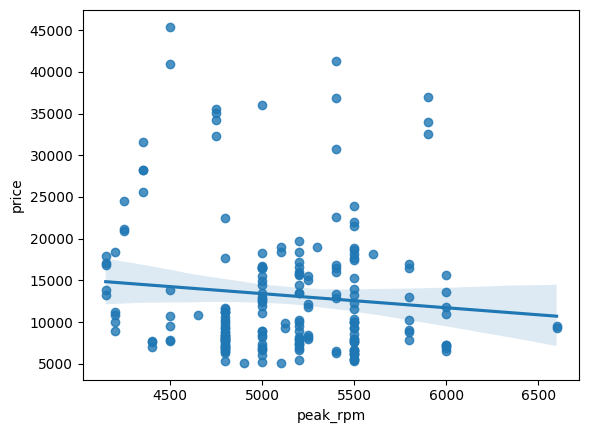

In [50]:
sns.regplot(x="peak_rpm", y="price", data=df_automobile)

In [51]:
pearson_coef, p_value = pearsonr(df_automobile["peak_rpm"], df_automobile["price"])

print(f"Pearson correlation: {pearson_coef}")
print(f"P_value: {p_value}")

Pearson correlation: -0.10161587407588149
P_value: 0.1511769165144528


* Pearson correlation

* There is a weak correlation between the variable 'stroke' and 'price.' as such regression will not work well

In [52]:
# Select only numeric columns for correlation
numeric_df = df_automobile.select_dtypes(include=['float64', 'int64'])
numeric_df.corr()

,symboling,wheel_base,length,width,height,curb_weight,engine_size,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
symboling,1.000000,-0.535987,-0.365404,-0.242423,-0.550160,-0.233118,-0.110581,-0.182196,0.075819,0.279740,-0.035527,0.036233,-0.082391
wheel_base,-0.535987,1.000000,0.876024,0.814507,0.590742,0.782097,0.572027,0.250313,0.371147,-0.360305,-0.470606,-0.543304,0.584642
length,-0.365404,0.876024,1.000000,0.857170,0.492063,0.880665,0.685025,0.159733,0.579821,-0.285970,-0.665192,-0.698142,0.690628
width,-0.242423,0.814507,0.857170,1.000000,0.306002,0.866201,0.729436,0.189867,0.615077,-0.245800,-0.633531,-0.680635,0.751265
height,-0.550160,0.590742,0.492063,0.306002,1.000000,0.307581,0.074694,0.259737,-0.087027,-0.309974,-0.049800,-0.104812,0.135486
curb_weight,-0.233118,0.782097,0.880665,0.866201,0.307581,1.000000,0.849072,0.156433,0.757976,-0.279361,-0.749543,-0.794889,0.834415
engine_size,-0.110581,0.572027,0.685025,0.729436,0.074694,0.849072,1.000000,0.028889,0.822676,-0.256733,-0.650546,-0.679571,0.872335
compression_ratio,-0.182196,0.250313,0.159733,0.189867,0.259737,0.156433,0.028889,1.000000,-0.214514,-0.435780,0.331425,0.268465,0.071107
horsepower,0.075819,0.371147,0.579821,0.615077,-0.087027,0.757976,0.822676,-0.214514,1.000000,0.107885,-0.822214,-0.804575,0.809575
peak_rpm,0.279740,-0.360305,-0.285970,-0.245800,-0.309974,-0.279361,-0.256733,-0.435780,0.107885,1.000000,-0.115413,-0.058598,-0.101616


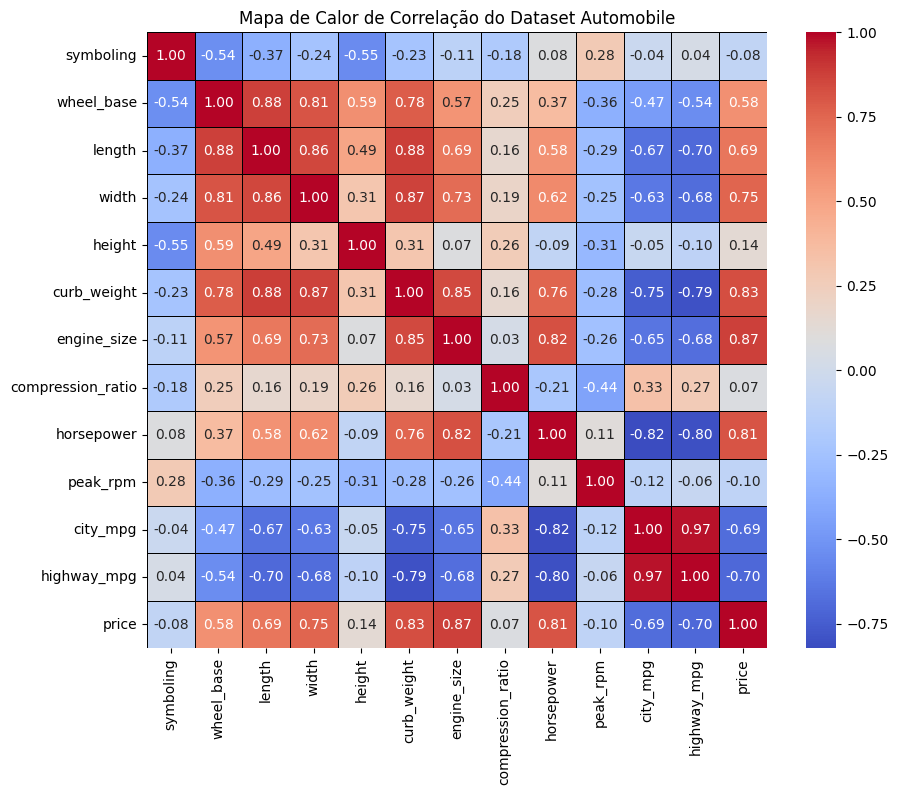

In [53]:
# 1. Importar as bibliotecas
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Carregar os dados (usando um dataset de exemplo do seaborn)
# Substitua esta linha para carregar seu próprio arquivo, como:
# df = pd.read_csv('seu_arquivo.csv')
# df = sns.load_dataset('iris')

# 3. Calcular a matriz de correlação
# O método `.corr()` calcula a correlação de Pearson por padrão
# entre as colunas numéricas.
matriz_correlacao = df_automobile.select_dtypes(include='number').corr()

# 4. Plotar o mapa de calor
# A função `sns.heatmap()` cria a visualização.
plt.figure(figsize=(10, 8)) # Opcional: define o tamanho da figura para melhor visualização
sns.heatmap(matriz_correlacao,
            annot=True,     # Exibe os valores numéricos em cada célula.
            cmap='coolwarm',# Escolhe uma paleta de cores divergente.
            fmt=".2f",      # Formata as anotações para duas casas decimais.
            linewidths=0.5, # Adiciona linhas entre as células para separá-las.
            linecolor='black')
plt.title('Mapa de Calor de Correlação do Dataset Automobile')
plt.show()


# Chi-Square Test for Categorical Variables

In [54]:
import pandas as pd
from scipy.stats import chi2_contingency

# Create the contingency table
data = [[20, 30],  # Male: [Like, Dislike]
        [25, 25]]  # Female: [Like, Dislike]
# Create a DataFrame for clarity
df = pd.DataFrame(data, columns=["Like", "Dislike"], index=["Male", "Female"])
# Perform the Chi-Square Test
chi2, p, dof, expected = chi2_contingency(df)
# Display results
print("Chi-square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("P-value:", p)
print("Expected Frequencies:\n", expected)


Chi-square Statistic: 0.6464646464646464
Degrees of Freedom: 1
P-value: 0.4213795037428697
Expected Frequencies:
 [[22.5 27.5]
 [22.5 27.5]]


# Categorical Variables
These are variables that describe a 'characteristic' of a data unit, and are selected from a small group of categories. The categorical variables can have the type "object" or "int64". A good way to visualize categorical variables is by using boxplots.

<Axes: xlabel='body_style', ylabel='price'>

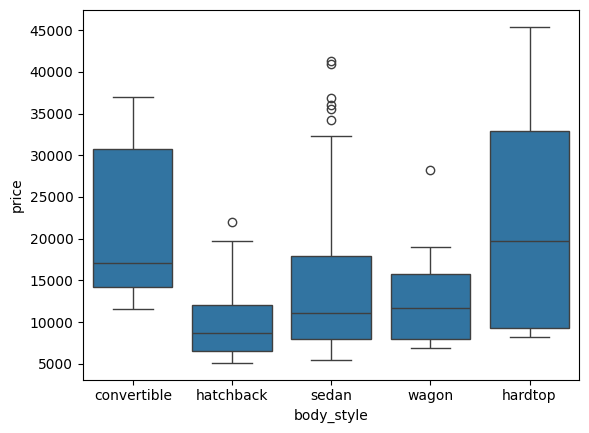

In [55]:
sns.boxplot(x="body_style", y="price", data=df_automobile)

We see that the distributions of price between the different body-style categories have a significant overlap, so body-style would not be a good predictor of price. Let's examine engine "engine-location" and "price":

<Axes: xlabel='engine_location', ylabel='price'>

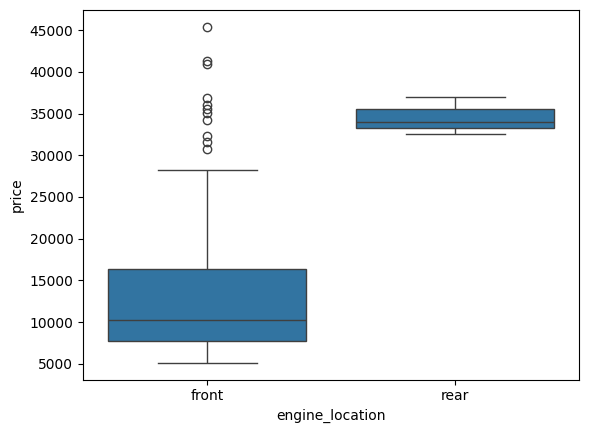

In [56]:
sns.boxplot(x="engine_location", y="price", data=df_automobile)

Here we see that the distribution of price between these two engine-location categories, front and rear, are distinct enough to take engine-location as a potential good predictor of price.

<Axes: xlabel='drive_wheels', ylabel='price'>

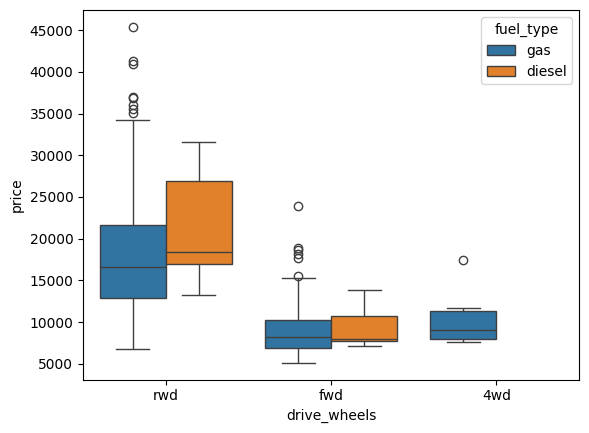

In [57]:
# drive-wheels
sns.boxplot(x="drive_wheels", y="price", hue="fuel_type", data=df_automobile)

Here we see that the distribution of price between the different drive-wheels categories differs. As such, drive-wheels could potentially be a predictor of price.

# Descriptive Statistical Analysis

The describe function automatically computes basic statistics for all continuous variables. Any NaN values are automatically skipped in these statistics.

the count of that variable
the mean
the standard deviation (std)
the minimum value
the IQR (Interquartile Range: 25%, 50% and 75%)
the maximum value

In [58]:
df_automobile.describe()

,symboling,wheel_base,length,width,height,curb_weight,engine_size,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,98.797015,174.200995,65.889055,53.766667,2555.666667,126.875622,10.164279,103.405534,5117.665368,25.179104,30.686567,13207.129353
std,1.254802,6.066366,12.322175,2.101471,2.447822,517.296727,41.546834,4.004965,37.365700,478.113805,6.423220,6.815150,7947.066342
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.800000,64.100000,52.000000,2169.000000,98.000000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,95.000000,5125.369458,24.000000,30.000000,10295.000000
75%,2.000000,102.400000,183.500000,66.600000,55.500000,2926.000000,141.000000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000


In [59]:
df_automobile.describe(include=['object'])

,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,engine_type,num_of_cylinders,fuel_system,bore,stroke
count,201.0,201,201,201,201,201,201,201,201,201,201,201,201
unique,52.0,22,2,2,2,5,3,2,6,7,8,39,37
top,122.0,toyota,gas,std,four,sedan,fwd,front,ohc,four,mpfi,3.62,3.40
freq,37.0,32,181,165,115,94,118,198,145,157,92,23,19


# Value Counts
Value counts is a good way of understanding how many units of each characteristic/variable we have. We can apply the "value_counts" method on the column "drive-wheels". Don’t forget the method "value_counts" only works on pandas series, not pandas dataframes. As a result, we only include one bracket df['drive-wheels'], not two brackets df[['drive-wheels']].

In [60]:
df_automobile['drive_wheels'].value_counts()

drive_wheels
fwd    118
rwd     75
4wd      8
Name: count, dtype: int64

We can convert the series to a dataframe as follows:

In [61]:
df_automobile['drive_wheels'].value_counts().to_frame()

,count
drive_wheels,
fwd,118
rwd,75
4wd,8


In [62]:
drive_wheels_counts = df_automobile['drive_wheels'].value_counts().to_frame()
drive_wheels_counts.reset_index(inplace=True)
drive_wheels_counts=drive_wheels_counts.rename(columns={'drive_wheels': 'value_counts'})
drive_wheels_counts

,value_counts,count
0,fwd,118
1,rwd,75
2,4wd,8


In [63]:
drive_wheels_counts.index.name = 'drive_wheels'
drive_wheels_counts

,value_counts,count
drive_wheels,,
0,fwd,118
1,rwd,75
2,4wd,8


In [64]:
# engine-location as variable
engine_loc_counts = df_automobile['engine_location'].value_counts().to_frame()
engine_loc_counts.rename(columns={'engine_location': 'value_counts'}, inplace=True)
engine_loc_counts.index.name = 'engine_location'
engine_loc_counts.head(10)

,count
engine_location,
front,198
rear,3


# Basics of Grouping
The "groupby" method groups data by different categories. The data is grouped based on one or several variables, and analysis is performed on the individual groups.

For example, let's group by the variable "drive-wheels". We see that there are 3 different categories of drive wheels.

In [65]:
df_automobile['drive_wheels'].unique()

array(['rwd', 'fwd', '4wd'], dtype=object)

If we want to know, on average, which type of drive wheel is most valuable, we can group "drive-wheels" and then average them.
We can select the columns 'drive-wheels', 'body-style' and 'price', then assign it to the variable "df_group_one".

In [66]:
df_group_one = df_automobile[['drive_wheels','body_style','price']]

We can then calculate the average price for each of the different categories of data.

In [67]:
# grouping results
df_grouped = df_group_one.groupby(['drive_wheels'], as_index=False).agg({'price': 'mean'})
df_grouped

,drive_wheels,price
0,4wd,10241.000000
1,fwd,9244.779661
2,rwd,19757.613333


From our data, it seems rear-wheel drive vehicles are, on average, the most expensive, while 4-wheel and front-wheel are approximately the same in price.
You can also group by multiple variables. For example, let's group by both 'drive-wheels' and 'body-style'. This groups the dataframe by the unique combination of 'drive-wheels' and 'body-style'. We can store the results in the variable 'grouped_test1'.

In [68]:
# grouping results
df_gptest = df_automobile[['drive_wheels','body_style','price']]
grouped_test1 = df_gptest.groupby(['drive_wheels','body_style'],as_index=False).mean()
grouped_test1

,drive_wheels,body_style,price
0,4wd,hatchback,7603.000000
1,4wd,sedan,12647.333333
2,4wd,wagon,9095.750000
3,fwd,convertible,11595.000000
4,fwd,hardtop,8249.000000
5,fwd,hatchback,8396.387755
6,fwd,sedan,9811.800000
7,fwd,wagon,9997.333333
8,rwd,convertible,23949.600000
9,rwd,hardtop,24202.714286


This grouped data is much easier to visualize when it is made into a pivot table. A pivot table is like an Excel spreadsheet, with one variable along the column and another along the row. We can convert the dataframe to a pivot table using the method "pivot" to create a pivot table from the groups.

In this case, we will leave the drive-wheels variable as the rows of the table, and pivot body-style to become the columns of the table:

In [69]:
grouped_pivot = grouped_test1.pivot(index='drive_wheels',columns='body_style')
grouped_pivot

price                                            \
body_style   convertible       hardtop     hatchback         sedan   
drive_wheels                                                         
4wd                  NaN           NaN   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body_style           wagon  
drive_wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

Often, we won't have data for some of the pivot cells. We can fill these missing cells with the value 0, but any other value could potentially be used as well. It should be mentioned that missing data is quite a complex subject and is an entire course on its own.

In [70]:
grouped_pivot = grouped_pivot.fillna(0) #fill missing values with 0
grouped_pivot

price                                            \
body_style   convertible       hardtop     hatchback         sedan   
drive_wheels                                                         
4wd                  0.0      0.000000   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body_style           wagon  
drive_wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

In [71]:
# grouping results
df_gptest2 = df_automobile[['body_style','price']]
grouped_test_bodystyle = df_gptest2.groupby(['body_style'],as_index= False).mean()
grouped_test_bodystyle

,body_style,price
0,convertible,21890.500000
1,hardtop,22208.500000
2,hatchback,9957.441176
3,sedan,14459.755319
4,wagon,12371.960000


In [72]:
import matplotlib.pyplot as plt
%matplotlib inline 

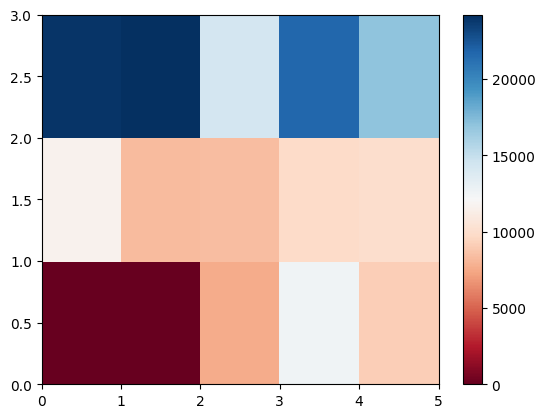

In [73]:
#use the grouped results
plt.pcolor(grouped_pivot, cmap='RdBu')
plt.colorbar()
plt.show()

The heatmap plots the target variable (price) proportional to colour with respect to the variables 'drive-wheel' and 'body-style' on the vertical and horizontal axis, respectively. This allows us to visualize how the price is related to 'drive-wheel' and 'body-style'.

The default labels convey no useful information to us. Let's change that:

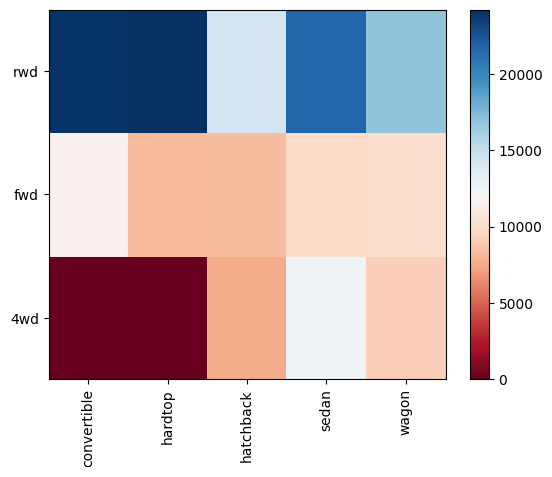

In [74]:
fig, ax = plt.subplots()
im = ax.pcolor(grouped_pivot, cmap='RdBu')

#label names
row_labels = grouped_pivot.columns.levels[1]
col_labels = grouped_pivot.index

#move ticks and labels to the center
ax.set_xticks(np.arange(grouped_pivot.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(grouped_pivot.shape[0]) + 0.5, minor=False)

#insert labels
ax.set_xticklabels(row_labels, minor=False)
ax.set_yticklabels(col_labels, minor=False)

#rotate label if too long
plt.xticks(rotation=90)

fig.colorbar(im)
plt.show()

# Correlation

In [75]:
from scipy import stats

In [76]:
from scipy.stats import pearsonr

pearson_coef, p_value = pearsonr(df_automobile["wheel_base"], df_automobile["price"])

print(f"Pearson correlation: {pearson_coef}")
print(f"P_value: {p_value}")

Pearson correlation: 0.584641822265508
P_value: 8.076488270732847e-20


* Conclusion:
Since the p-value is < 0.001, the correlation between wheel-base and price is statistically significant, although the linear relationship isn't extremely strong (~0.585).

In [77]:
 for param in ['wheel_base', 'body_style','engine_location','highway_mpg']:
     print(param)
    

wheel_base
body_style
engine_location
highway_mpg


# Linear Regression Model

In [78]:
!pip install -U scikit-learn

In [79]:
from sklearn.linear_model import LinearRegression

lm = LinearRegression()


* Simple linear regression 

In [80]:
X = df_automobile[['highway_mpg']]

In [81]:
Y = df_automobile[['price']]

In [82]:
lm.fit(X, Y)

# Extract the intercept point
intercept = lm.intercept_

# Extract the coefficient (slope)
coef = lm.coef_

In [83]:
* Mltiple linear regression 

SyntaxError: invalid syntax (1083062265.py, line 1)

In [84]:
Z = df_automobile[['horsepower', 'curb_weight', 'engine_size', 'highway_mpg']]

In [85]:
Y = df_automobile[['price']]

In [86]:
lm.fit(Z, df_automobile[['price']])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [88]:
intercept = lm.intercept_

In [89]:
intercept

array([-15806.62462633])

In [90]:
coef = lm.coef_

In [91]:
coef

array([[53.49574423,  4.70770099, 81.53026382, 36.05748882]])

In [92]:
import seaborn as sns

<Axes: xlabel='highway_mpg', ylabel='price'>

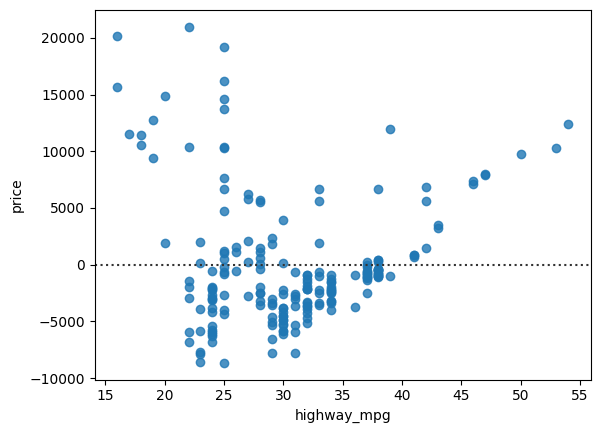

In [93]:
sns.residplot(x='highway_mpg', y='price', data=df_automobile)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create a DataFrame for structured data
np.random.seed(42)
df = pd.DataFrame({
    'Category A': np.random.normal(0, 1, 100),
    'Category B': np.random.normal(1, 1.5, 100),
    'Category C': np.random.normal(-0.5, 0.8, 100)
})

# Create the box plot
sns.boxplot(data=df)

# Add labels and title
plt.title("Box Plot of Categories")
plt.xlabel("Category")
plt.ylabel("Values")

# Show the plot
plt.show()